# Exploratory Data Analysis — South African Retail Trade Sales (Corrected Data)

**Target:** Total retail trade sales, **constant 2019 prices, not seasonally adjusted** (Stats SA P6242.1), Jan 1986 – May 2026.

This EDA is run on the *corrected* dataset. The previous target was an aggregation
artifact (all category rows were averaged because the H01–H05 label columns were
dropped, blending constant/current prices, seasonally-adjusted/not, and totals/
sub-categories). That produced a spurious 2004 block. The corrected target selects
the single published Total row and growth-splices the 1995→2019 base change, and it
matches the official Stats SA May 2026 release exactly. See the accompanying
`build_retail_dataset_corrected.py` for provenance.

Findings here that differ from the earlier EDA (and why):
- **No Jan 2004 outlier** — it was a data-aggregation artifact, now removed at source.
  The only extreme month-on-month move is the real **May 2020 COVID rebound**.
- **CPI as inflation, not level** — on a constant-price (real) target, the CPI *level*
  is ~0.98 correlated with the trend, so it is a trend proxy, not an economic signal.
  CPI *year-on-year inflation* carries the genuine (negative) demand signal.
- **No structural-break dummy** — the earlier Dec-2003 Zivot–Andrews break was driven
  by the 2004 artifact; on corrected data there is no such level break.
- **Electricity re-assessed** — the earlier "CV=31, drop for noise" was an artifact of
  the same blending bug (and of applying CV to a near-flat, near-zero-mean series). The
  corrected national production index (base 2019=100) is smooth.

## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
    from statsmodels.tsa.seasonal import seasonal_decompose
    HAS_STATSMODELS = True
    print('statsmodels available — full ADF/decompose will run')
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not installed — autocorrelation proxy used')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})
PALETTE = {'primary': '#185FA5', 'positive': '#1D9E75', 'negative': '#E24B4A',
           'caution': '#EF9F27', 'neutral': '#888780'}
print('Setup complete.')

statsmodels available — full ADF/decompose will run
Setup complete.


In [2]:
# Load corrected dataset
df = pd.read_csv('final_model_dataset_corrected.csv', sep=';')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Full series runs to May 2026 (target only). Exogenous covariates end Dec 2025 and are
# frozen thereafter; for EDA of relationships we analyse the training window to Dec 2025.
df_full = df.copy()
df = df.loc[:'2025-12-31']

TARGET = 'retail_sales'
MACRO_VARS  = ['cpi', 'cpi_yoy', 'exchangeRate', 'electricity']
CCI_VARS    = ['cci_net_balance', 'cci_expected_economic_performance',
               'cci_expected_household_finances', 'cci_time2buy_durables_net', 'cci_level']
LAG_VARS    = ['retail_lag_1', 'retail_lag_3', 'retail_lag_6']
GROWTH_VARS = ['retail_growth', 'electricity_growth']

# Derive CPI year-on-year inflation (the economic signal on a real target)
df['cpi_yoy'] = df['cpi'].pct_change(12) * 100
df_full['cpi_yoy'] = df_full['cpi'].pct_change(12) * 100
ALL_FEATURES = MACRO_VARS + CCI_VARS + LAG_VARS + GROWTH_VARS

print(f'Dataset shape  : {df.shape}')
print(f'Analysis window: {df.index.min().date()} to {df.index.max().date()}  (to Dec 2025)')
print(f'Target basis   : constant 2019 prices, NSA (R million)')
print(f'Missing values : {df[[TARGET]].isnull().sum().sum()} in target')

Dataset shape  : (480, 15)
Analysis window: 1986-01-31 to 2025-12-31  (to Dec 2025)
Target basis   : constant 2019 prices, NSA (R million)
Missing values : 0 in target


## 2. Dataset overview

In [3]:
desc = df.describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(4)
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'cv']]
desc.columns = ['N', 'Mean', 'Std', 'Min', 'P25', 'Median', 'P75', 'Max', 'CV']
print('Descriptive statistics (CV = coefficient of variation):')
print(desc.round(2).to_string())
print()
print(f"Target 1986 mean = {df.loc['1986', TARGET].mean():,.0f}  |  2025 mean = {df.loc['2025', TARGET].mean():,.0f}")
print("Scale is now the true constant-2019 total (~R100bn/month in 2025), not the old ~R28bn blend.")

Descriptive statistics (CV = coefficient of variation):
                                       N      Mean       Std       Min       P25    Median       P75        Max     CV
retail_sales                       480.0  65188.87  24388.35  33036.14  41843.04  65115.50  86466.50  138834.00   0.37
cpi                                480.0     89.97     56.88     12.99     42.04     73.09    132.69     211.32   0.63
electricity                        480.0     87.46     15.11     50.90     75.47     91.75     99.70     113.00   0.17
cci_net_balance                    480.0     -1.70     11.63    -32.49     -9.22     -3.00      6.00      26.00   6.86
cci_expected_economic_performance  480.0     -1.86     16.26    -38.71    -14.00     -3.00     11.00      34.00   8.75
cci_expected_household_finances    480.0      9.15      9.53    -19.00      3.00      9.38     15.00      31.00   1.04
cci_time2buy_durables_net          480.0    -12.17     12.30    -63.61    -20.02    -13.00     -4.00      13.00

## 3. Time series plots

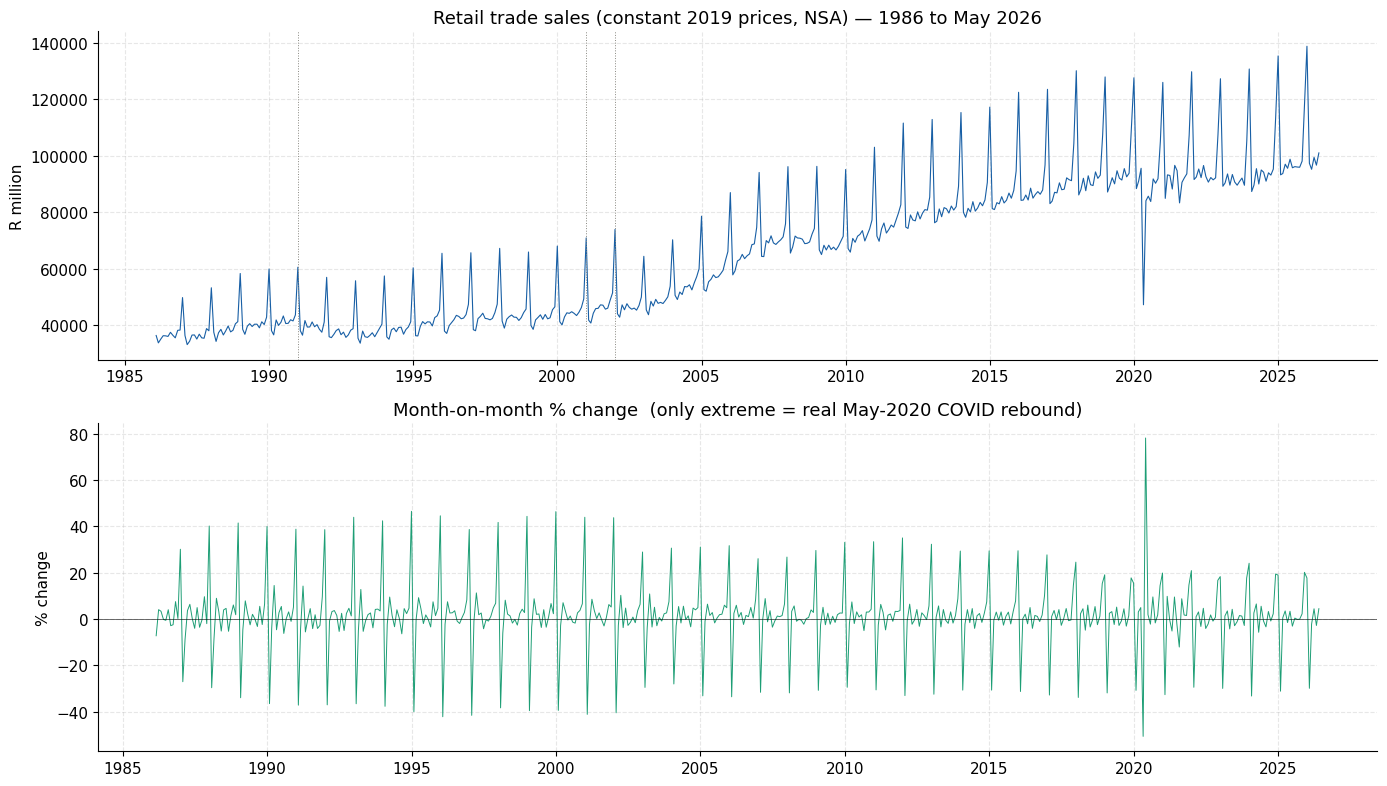

Max |MoM growth| = 78.2% at 2020-05-31 (COVID). No 2004 artifact.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df_full.index, df_full[TARGET], color=PALETTE['primary'], lw=0.8)
axes[0].set_title('Retail trade sales (constant 2019 prices, NSA) — 1986 to May 2026')
axes[0].set_ylabel('R million')
for b in ['1991-01-01', '2001-01-01', '2002-01-01']:
    axes[0].axvline(pd.Timestamp(b), color=PALETTE['neutral'], ls=':', lw=0.7)
g = df_full[TARGET].pct_change() * 100
axes[1].plot(df_full.index, g, color=PALETTE['positive'], lw=0.7)
axes[1].axhline(0, color='k', lw=0.4)
axes[1].set_title('Month-on-month % change  (only extreme = real May-2020 COVID rebound)')
axes[1].set_ylabel('% change')
plt.tight_layout(); plt.savefig('plot_eda_01_series.png', dpi=150, bbox_inches='tight'); plt.show()
print('Max |MoM growth| = %.1f%% at %s (COVID). No 2004 artifact.' % (g.abs().max(), g.abs().idxmax().date()))

## 4. Correlation analysis

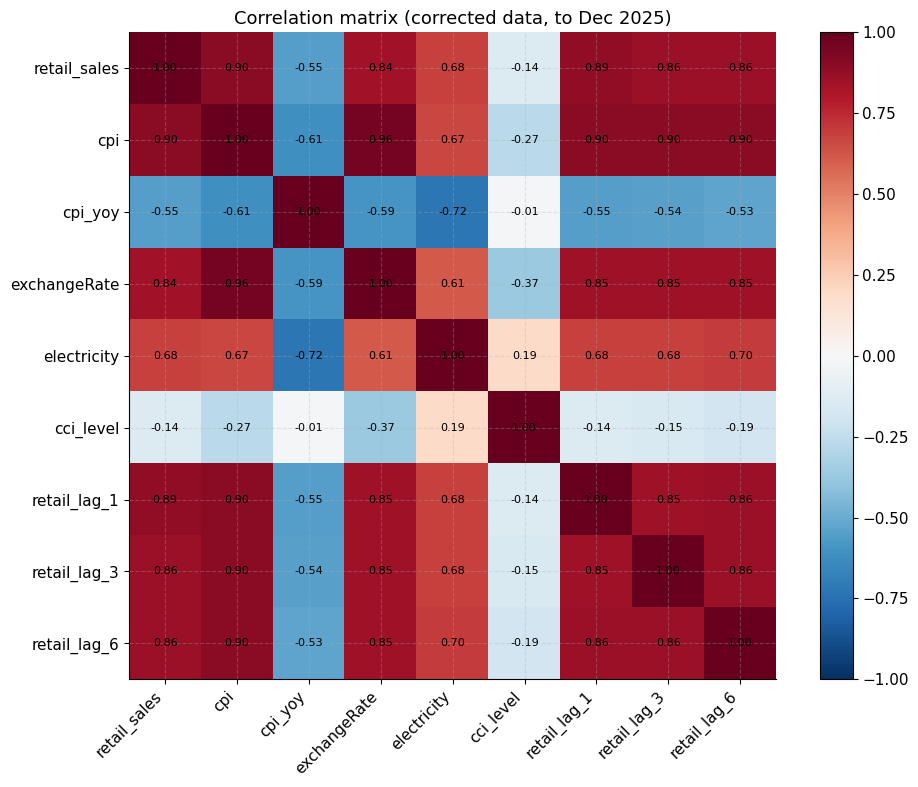

Correlation with retail_sales:
cpi_yoy        -0.552
cci_level      -0.136
electricity     0.681
exchangeRate    0.843
retail_lag_6    0.859
retail_lag_3    0.862
retail_lag_1    0.887
cpi             0.902


In [5]:
cols = [TARGET, 'cpi', 'cpi_yoy', 'exchangeRate', 'electricity', 'cci_level'] + LAG_VARS
corr = df[cols].corr().round(2)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, fraction=0.046); ax.set_title('Correlation matrix (corrected data, to Dec 2025)')
plt.tight_layout(); plt.savefig('plot_eda_02_corr.png', dpi=150, bbox_inches='tight'); plt.show()

ct = df[cols].corr()[TARGET].drop(TARGET).sort_values()
print('Correlation with retail_sales:'); print(ct.round(3).to_string())

### 4a. CPI level vs inflation — the key covariate decision

On a **constant-price (real)** target, is CPI an economic signal or just a trend proxy?

cpi (level)   vs retail : r = 0.902
cpi (level)   vs trend  : r = 0.980   <-- near-perfect trend proxy
cpi_yoy (infl) vs retail: r = -0.552   <-- genuine (negative) demand signal
cpi vs exchangeRate     : r = 0.964   (collinear, as before)

DECISION: enter CPI as year-on-year inflation (cpi_yoy), NOT the level.
The level duplicates the trend feature and, on a real target, re-introduces the
inflation that constant prices already removed. Inflation is the real signal.


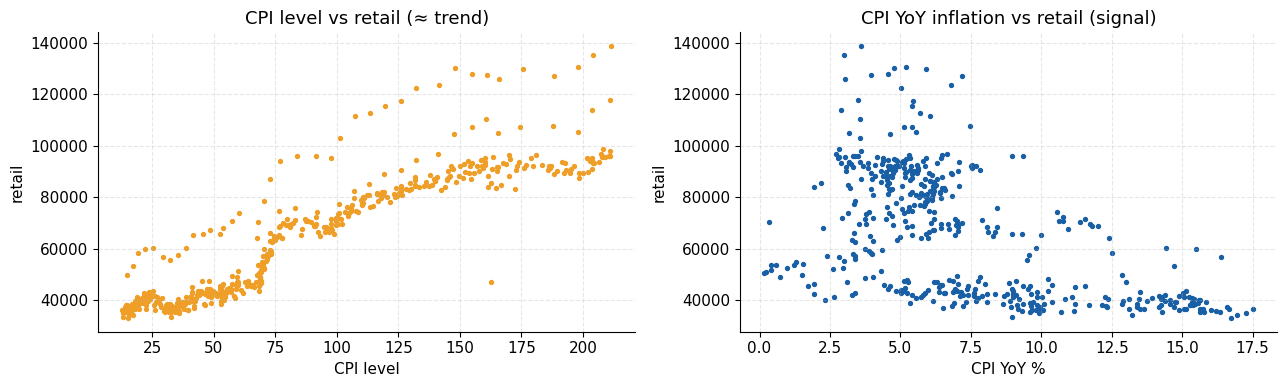

In [6]:
tr = df.copy(); tr['trend'] = np.arange(len(tr))
print('cpi (level)   vs retail : r = %.3f' % tr[['cpi', TARGET]].corr().iloc[0, 1])
print('cpi (level)   vs trend  : r = %.3f   <-- near-perfect trend proxy' % tr[['cpi', 'trend']].corr().iloc[0, 1])
print('cpi_yoy (infl) vs retail: r = %.3f   <-- genuine (negative) demand signal' % tr[['cpi_yoy', TARGET]].corr().iloc[0, 1])
print('cpi vs exchangeRate     : r = %.3f   (collinear, as before)' % tr[['cpi', 'exchangeRate']].corr().iloc[0, 1])
print()
print('DECISION: enter CPI as year-on-year inflation (cpi_yoy), NOT the level.')
print('The level duplicates the trend feature and, on a real target, re-introduces the')
print('inflation that constant prices already removed. Inflation is the real signal.')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(tr['cpi'], tr[TARGET], s=8, color=PALETTE['caution']); ax[0].set_title('CPI level vs retail (≈ trend)')
ax[0].set_xlabel('CPI level'); ax[0].set_ylabel('retail')
ax[1].scatter(tr['cpi_yoy'], tr[TARGET], s=8, color=PALETTE['primary']); ax[1].set_title('CPI YoY inflation vs retail (signal)')
ax[1].set_xlabel('CPI YoY %'); ax[1].set_ylabel('retail')
plt.tight_layout(); plt.savefig('plot_eda_03_cpi.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Stationarity diagnostics

In [7]:
ORIG_COLS = ['retail_sales', 'cpi', 'cpi_yoy', 'exchangeRate', 'electricity',
             'cci_level', 'retail_growth', 'electricity_growth']
rows = []
for col in ORIG_COLS:
    s = df[col].dropna()
    ac1 = s.autocorr(lag=1)
    if HAS_STATSMODELS:
        stat, p, *_ = adfuller(s, autolag='AIC')
        rows.append({'Variable': col, 'AC lag1': round(ac1, 3),
                     'ADF stat': round(stat, 3), 'p-value': round(p, 4),
                     'Stationary': 'YES' if p < 0.05 else 'NO'})
    else:
        rows.append({'Variable': col, 'AC lag1': round(ac1, 3)})
print(pd.DataFrame(rows).set_index('Variable').to_string())
if HAS_STATSMODELS:
    yl = df[TARGET].dropna()
    print('\nTarget: ADF level p=%.3f (non-stationary) -> ADF 1st-diff p=%.4f (stationary): difference d=1.'
          % (adfuller(yl)[1], adfuller(yl.diff().dropna())[1]))

                    AC lag1  ADF stat  p-value Stationary
Variable                                                 
retail_sales          0.887     0.153   0.9695         NO
cpi                   1.000     3.215   1.0000         NO
cpi_yoy               0.988    -2.180   0.2135         NO
exchangeRate          0.996    -0.633   0.8634         NO
electricity           0.951    -2.181   0.2133         NO
cci_level             0.919    -3.741   0.0036        YES
retail_growth        -0.376    -5.070   0.0000        YES
electricity_growth   -0.462    -4.387   0.0003        YES

Target: ADF level p=0.969 (non-stationary) -> ADF 1st-diff p=0.0000 (stationary): difference d=1.


## 6. Seasonality analysis

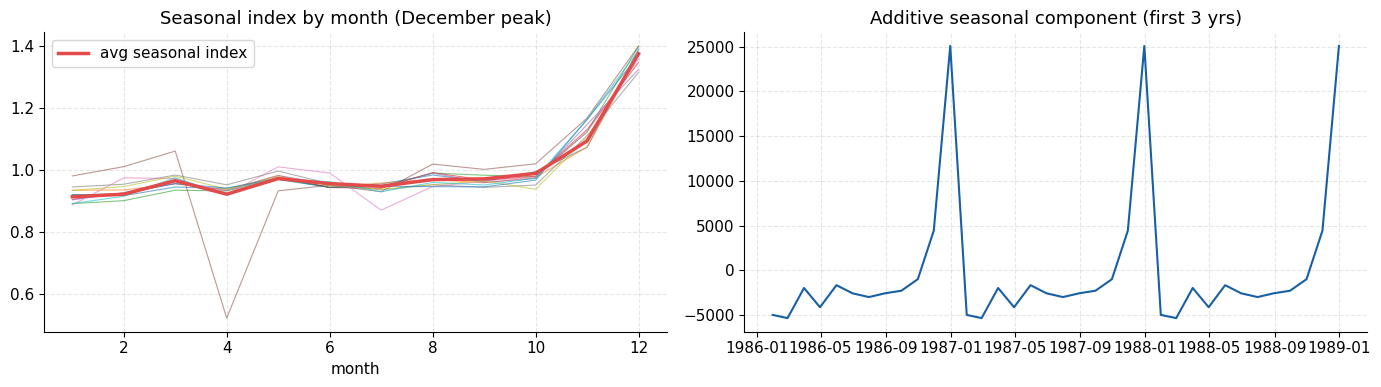

December seasonal index = 1.37  |  ACF at lag 12 = 0.99 (seasonal anchor).
NOTE: mild seasonality regime difference pre/post-2002 (survey redesign) — disclose in paper.


In [8]:
df['month'] = df.index.month; df['year'] = df.index.year
piv = df[df['year'] >= 2005].pivot_table(index='month', columns='year', values=TARGET)
seas = (piv.div(piv.mean(axis=0), axis=1)).mean(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for yy in range(2015, 2026):
    if yy in piv.columns:
        ax[0].plot(piv.index, piv[yy] / piv[yy].mean(), lw=0.8, alpha=0.6)
ax[0].plot(seas.index, seas.values, color=PALETTE['negative'], lw=2.5, label='avg seasonal index')
ax[0].set_title('Seasonal index by month (December peak)'); ax[0].set_xlabel('month'); ax[0].legend()
if HAS_STATSMODELS:
    dec = seasonal_decompose(df[TARGET].dropna(), model='additive', period=12)
    ax[1].plot(dec.seasonal.iloc[:36].index, dec.seasonal.iloc[:36].values, color=PALETTE['primary'])
    ax[1].set_title('Additive seasonal component (first 3 yrs)')
plt.tight_layout(); plt.savefig('plot_eda_04_seasonality.png', dpi=150, bbox_inches='tight'); plt.show()
print('December seasonal index = %.2f  |  ACF at lag 12 = %.2f (seasonal anchor).'
      % (seas.loc[12], df[TARGET].dropna().autocorr(12)))
print('NOTE: mild seasonality regime difference pre/post-2002 (survey redesign) — disclose in paper.')

## 7. Distribution diagnostics — growth & the Jan-2004 question

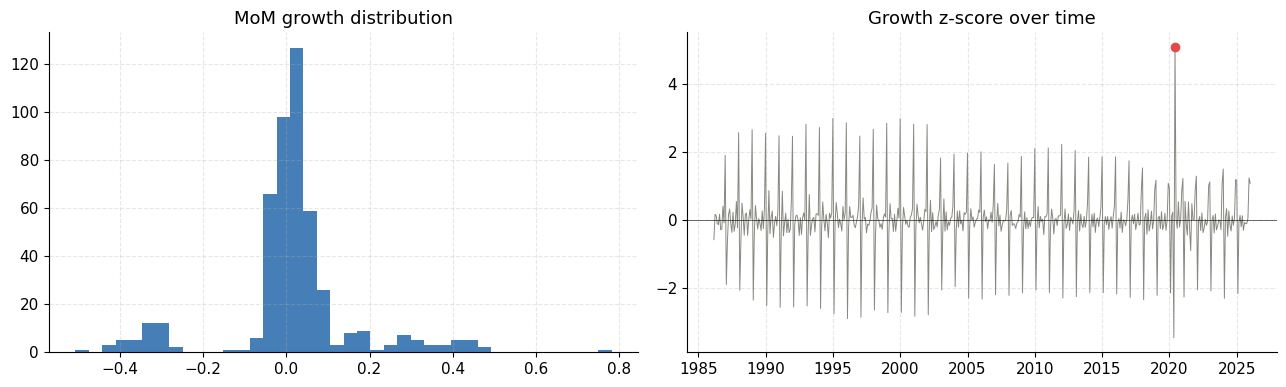

Corrected data: max |z| = 5.1 at 2020-05-31 (real COVID), kurtosis = 3.8.
Contrast: the earlier blended series had a Jan-2004 z ~ 21.6 — a pure aggregation artifact,
now removed at source. Winsorisation is therefore no longer needed to tame Jan 2004;
if applied at all it should be light and origin-relative (train-only bounds), and it
mainly clips the genuine COVID month. Winsor [1%,99%] bounds = [-0.401, 0.440].


In [9]:
rg = df['retail_growth'].dropna()
z = (rg - rg.mean()) / rg.std()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(rg, bins=40, color=PALETTE['primary'], alpha=0.8); ax[0].set_title('MoM growth distribution')
ax[1].plot(rg.index, z, color=PALETTE['neutral'], lw=0.7); ax[1].axhline(0, color='k', lw=0.4)
ax[1].set_title('Growth z-score over time'); ax[1].scatter([z.abs().idxmax()], [z.loc[z.abs().idxmax()]], color=PALETTE['negative'], zorder=5)
plt.tight_layout(); plt.savefig('plot_eda_05_growth.png', dpi=150, bbox_inches='tight'); plt.show()
print('Corrected data: max |z| = %.1f at %s (real COVID), kurtosis = %.1f.'
      % (z.abs().max(), z.abs().idxmax().date(), rg.kurtosis()))
print('Contrast: the earlier blended series had a Jan-2004 z ~ 21.6 — a pure aggregation artifact,')
print('now removed at source. Winsorisation is therefore no longer needed to tame Jan 2004;')
print('if applied at all it should be light and origin-relative (train-only bounds), and it')
print('mainly clips the genuine COVID month. Winsor [1%%,99%%] bounds = [%.3f, %.3f].'
      % (rg.quantile(0.01), rg.quantile(0.99)))

## 8. Multicollinearity analysis

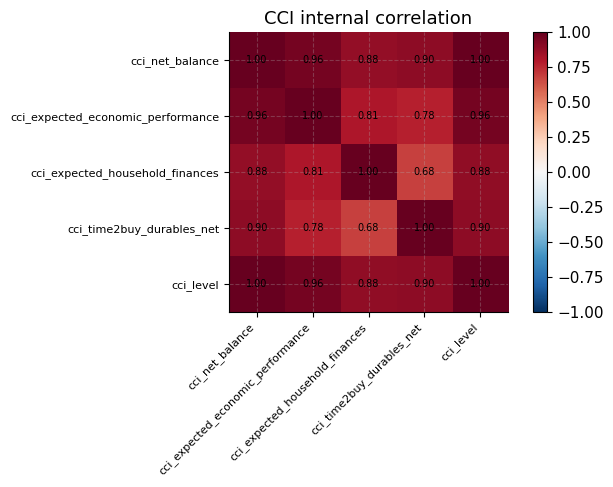

cci_net_balance ~ cci_level r = 0.999 (retain one representative).
cpi ~ exchangeRate r = 0.964 (retain one; prefer cpi_yoy as inflation).


In [10]:
cci_corr = df[CCI_VARS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cci_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CCI_VARS))); ax.set_xticklabels(CCI_VARS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(CCI_VARS))); ax.set_yticklabels(CCI_VARS, fontsize=8)
for i in range(len(CCI_VARS)):
    for j in range(len(CCI_VARS)):
        ax.text(j, i, f'{cci_corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('CCI internal correlation'); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig('plot_eda_06_cci.png', dpi=150, bbox_inches='tight'); plt.show()
print('cci_net_balance ~ cci_level r = %.3f (retain one representative).'
      % cci_corr.loc['cci_net_balance', 'cci_level'])
print('cpi ~ exchangeRate r = %.3f (retain one; prefer cpi_yoy as inflation).'
      % df[['cpi', 'exchangeRate']].corr().iloc[0, 1])

## 9. Electricity re-assessment (corrected national production index)

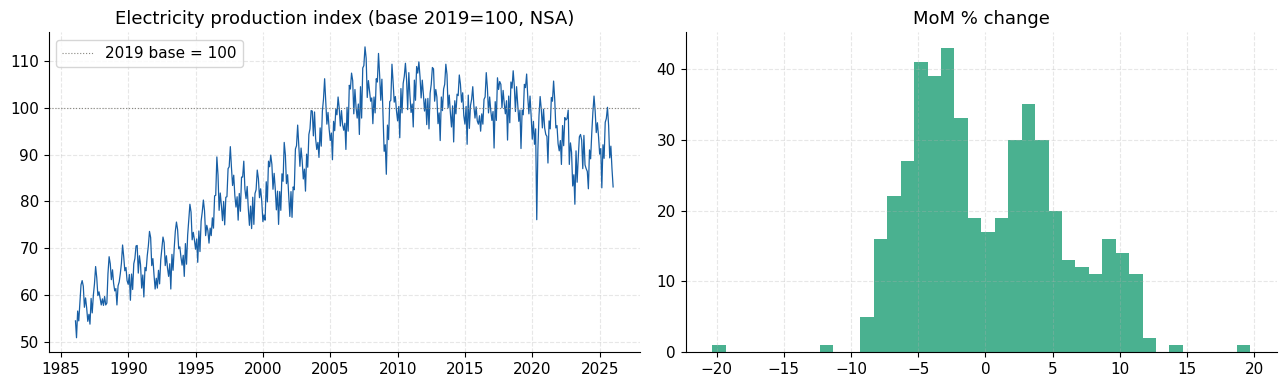

Corrected electricity index: 1986=57.5, 2019=100.0, 2025=91.5 (declining = load-shedding era).
Growth CV = 23.2. This is HIGH only because production is near-flat (mean growth ~0),
which makes CV = |std/mean| explode — it is NOT genuine noise. The earlier "CV=31, drop"
rule was an artifact of the blend AND of the metric. Decide inclusion via the ablation.


In [11]:
el = df['electricity'].dropna()
elg = el.pct_change().dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(el.index, el, color=PALETTE['primary'], lw=0.9)
ax[0].axhline(100, color=PALETTE['neutral'], ls=':', lw=0.8, label='2019 base = 100')
ax[0].set_title('Electricity production index (base 2019=100, NSA)'); ax[0].legend()
ax[1].hist(elg * 100, bins=40, color=PALETTE['positive'], alpha=0.8); ax[1].set_title('MoM % change')
plt.tight_layout(); plt.savefig('plot_eda_07_electricity.png', dpi=150, bbox_inches='tight'); plt.show()
cv_growth = abs(elg.std() / elg.mean())
print('Corrected electricity index: 1986=%.1f, 2019=%.1f, 2025=%.1f (declining = load-shedding era).'
      % (df.loc['1986','electricity'].mean(), df.loc['2019','electricity'].mean(), df.loc['2025','electricity'].mean()))
print('Growth CV = %.1f. This is HIGH only because production is near-flat (mean growth ~0),' % cv_growth)
print('which makes CV = |std/mean| explode — it is NOT genuine noise. The earlier "CV=31, drop"')
print('rule was an artifact of the blend AND of the metric. Decide inclusion via the ablation.')

## 10. Variable verdict & recommendations (corrected data)

In [12]:
FEATS = ['cpi', 'cpi_yoy', 'exchangeRate', 'electricity', 'cci_level'] + LAG_VARS
tr = df.copy(); tr['trend'] = np.arange(len(tr))
corr_lvl = tr.corr()[TARGET]
rows = []
for c in FEATS:
    cl = round(corr_lvl.get(c, np.nan), 3)
    tcorr = round(tr[[c, 'trend']].corr().iloc[0, 1], 3) if c in tr else np.nan
    if c in LAG_VARS:
        v = 'KEEP (autoregressive)'
    elif c == 'cpi':
        v = 'DROP level -> use cpi_yoy (level ~ trend, r_trend=%.2f)' % tcorr
    elif c == 'cpi_yoy':
        v = 'KEEP (inflation = real demand signal)'
    elif c == 'exchangeRate':
        v = 'CAUTION (collinear with cpi; alternative only)'
    elif c == 'electricity':
        v = 'TEST via ablation (corrected index, not noisy)'
    elif c == 'cci_level':
        v = 'KEEP one CCI representative (weak)'
    else:
        v = 'CAUTION'
    rows.append({'Variable': c, 'Corr(level)': cl, 'Corr(trend)': tcorr, 'Verdict': v})
print(pd.DataFrame(rows).set_index('Variable').to_string())

              Corr(level)  Corr(trend)                                                  Verdict
Variable                                                                                       
cpi                 0.902        0.980  DROP level -> use cpi_yoy (level ~ trend, r_trend=0.98)
cpi_yoy            -0.552       -0.696                    KEEP (inflation = real demand signal)
exchangeRate        0.843        0.942           CAUTION (collinear with cpi; alternative only)
electricity         0.681        0.791           TEST via ablation (corrected index, not noisy)
cci_level          -0.136       -0.173                       KEEP one CCI representative (weak)
retail_lag_1        0.887        0.908                                    KEEP (autoregressive)
retail_lag_3        0.862        0.907                                    KEEP (autoregressive)
retail_lag_6        0.859        0.907                                    KEEP (autoregressive)


In [13]:
print('=' * 74)
print('FINAL EDA RECOMMENDATIONS (corrected constant-2019 target)')
print('=' * 74)
print('''
TARGET
  Total retail trade sales, constant 2019 prices, NSA (matches official release).
  No Jan-2004 outlier (was an aggregation artifact). d=1 differencing; strong
  annual seasonality (Dec index ~1.4, ACF lag-12 ~0.9) -> keep NSA, model seasonality.

KEEP in all models
  retail_lag_1/3/6/12, rolling mean 3/6, rolling std 6   (autoregressive core)
  calendar: month, quarter, is_dec, is_nov, is_apr        (seasonality)
  trend                                                   (real growth)

COVARIATES (macro) — enter, but expect redundancy; confirm on the ROLLING-ORIGIN ablation
  cpi_yoy (inflation)  : genuine negative demand signal (r=-0.55); use INSTEAD of CPI level
  electricity          : corrected index; test via ablation (CV rule was an artifact)
  cci (one measure)    : weak; keep a single representative
  exchangeRate         : collinear with CPI; alternative only, not alongside

DROP / DO NOT USE
  cpi (level)          : ~0.98 correlated with trend -> pure trend proxy on a real target
  structural-break dummy: the old Dec-2003 break was the 2004 artifact; none on corrected data
  heavy winsorisation  : unnecessary; only extreme is the real May-2020 COVID month
                         (if used at all: light, origin-relative [1%,99%] train-only bounds)

EVALUATION NOTES (for the modelling notebook)
  * Holdout = Jan-May 2026, forecast from a FIXED Dec-2025 origin, direct multi-step h=1..5.
  * All conclusions (ablation, DM tests, conformal coverage) come from the ROLLING-ORIGIN
    walk-forward, not the 5-point holdout. Report MAPE (mean) and MdAPE (median) separately.
  * Re-estimate ARIMA & SARIMAX at every origin for a fair econometric-vs-ML comparison.
''')
print('=' * 74)

FINAL EDA RECOMMENDATIONS (corrected constant-2019 target)

TARGET
  Total retail trade sales, constant 2019 prices, NSA (matches official release).
  No Jan-2004 outlier (was an aggregation artifact). d=1 differencing; strong
  annual seasonality (Dec index ~1.4, ACF lag-12 ~0.9) -> keep NSA, model seasonality.

KEEP in all models
  retail_lag_1/3/6/12, rolling mean 3/6, rolling std 6   (autoregressive core)
  calendar: month, quarter, is_dec, is_nov, is_apr        (seasonality)
  trend                                                   (real growth)

COVARIATES (macro) — enter, but expect redundancy; confirm on the ROLLING-ORIGIN ablation
  cpi_yoy (inflation)  : genuine negative demand signal (r=-0.55); use INSTEAD of CPI level
  electricity          : corrected index; test via ablation (CV rule was an artifact)
  cci (one measure)    : weak; keep a single representative
  exchangeRate         : collinear with CPI; alternative only, not alongside

DROP / DO NOT USE
  cpi (level)     